# BDHS — Model Testing & Risk Cascade

**Notebook 4 of 4.** Loads the trained models from `models/` and runs the
mother–child risk cascade on synthetic patients.

## Why this is a separate notebook

Testing a model inside the notebook that trained it proves very little —
everything is already in memory, so the cascade would work whether or not the
saved files were any good. This notebook imports **nothing** from
`02_modelling.ipynb`. Every model, threshold, feature list, importance score and
preprocessing step is read from disk.

If this notebook runs, the artefacts are self-contained and could sit behind an
API unchanged. If it fails, they could not — however good the metrics looked
during training.

## What the report answers

Five outcomes for one mother, organised by when they happen:

| Phase | Outcome | Winning model | ROC-AUC |
|---|---|---|---|
| **Delivery** | facility delivery | Ensemble of 5 | 0.845 |
| **Newborn** | neonatal death | Ensemble of 3 | 0.773 |
| **Child (0–59 mo)** | stunting | CatBoost | 0.706 |
| | severe stunting | Ensemble of 4 | 0.700 |
| | underweight | TabM | 0.687 |

Three of the five winners are **greedy post-hoc ensembles** rather than single
estimators, and both of the other two are models that did not exist in the first
version of this project — CatBoost and TabM. Notebook 02 section 5b explains how
the ensembles are built and weighted.

"Ensemble of *n*" is the number of models carrying non-zero weight, not the size
of the candidate pool: all three searched the same seven candidates over fifteen
greedy steps and settled on five, three and four of them respectively.

All five are measured in both survey rounds, so no probability on the report
needs a footnote about which survey year it describes. That was not true of
earlier versions of this panel.

## Three things it does not answer

**No clinical complications.** DHS records no pre-eclampsia, gestational
diabetes, haemorrhage or sepsis — those columns are empty in both survey rounds.
Nothing here predicts them and no output should be read as doing so.

**Not a diagnosis.** These are population-level risk estimates from
socio-demographic inputs. A probability of 0.31 for stunting means roughly a
third of women with this profile have a stunted child, not that this child will
be. The report is built to support prioritisation of limited contact time, and
nothing more.

**Not equally certain across outcomes.** `facility_delivery` rests on 1,240 test
positives and `severe_stunting` on 179. The bootstrap intervals in notebook 02
differ by more than a factor of two, and the report shows every outcome at the
same visual weight — so the accompanying commentary, not the layout, is where
that difference lives.

## Prerequisites

`02_modelling.ipynb` run to completion, so `models/` holds one `.joblib` per
entry in `model_manifest.json` plus `anomaly_bundle.joblib`.

Runtime is seconds — nothing is retrained.

# 1. Load the saved artefacts

In [1]:
import json
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# The line above only covers THIS process. joblib/loky start worker processes
# from a clean interpreter and do not inherit it, so anything the saved
# pipelines fit out-of-process would still print. PYTHONWARNINGS is passed down
# through the environment and does cover those.
os.environ["PYTHONWARNINGS"] = "ignore"
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

DATA_DIR = Path.cwd()
MODEL_DIR = DATA_DIR / "models"
COHORT_DIR = DATA_DIR / "cohorts"

# ---------------------------------------------------------------------------
# Some winners are greedy ensembles rather than single pipelines. joblib
# pickles a class *by reference* -- the bundle stores the name
# "__main__.GreedyEnsemble", not the code -- so the class has to exist in this
# kernel's namespace before joblib.load() runs, or unpickling raises
# AttributeError.
#
# It is redefined here rather than imported, because notebook 02 defined it in
# its own __main__ and that is the name recorded in the file. The definition
# must stay behaviourally identical to 02's; the only thing pickle restores is
# the instance state (members and counts).
# ---------------------------------------------------------------------------
from sklearn.base import BaseEstimator, ClassifierMixin


def get_scores(pipe, X):
    """Probabilities where available, scaled decision scores otherwise."""
    if hasattr(pipe, "predict_proba"):
        try:
            return pipe.predict_proba(X)[:, 1]
        except (AttributeError, NotImplementedError):
            pass
    raw = pipe.decision_function(X)
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)


class GreedyEnsemble(ClassifierMixin, BaseEstimator):
    """Weighted average of fitted pipelines -- see notebook 02, section 5b."""

    def __init__(self, members=None, counts=None):
        self.members = members
        self.counts = counts

    def fit(self, X=None, y=None):
        total = sum(self.counts.values())
        self.weights_ = {k: v / total for k, v in self.counts.items() if v}
        self.classes_ = np.array([0, 1])
        return self

    @property
    def weights(self):
        if not hasattr(self, "weights_"):
            self.fit()
        return self.weights_

    def predict_proba(self, X):
        p = np.zeros(len(X), dtype=float)
        for name, w in self.weights.items():
            p += w * get_scores(self.members[name], X)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def __repr__(self):
        if not self.counts:
            return "GreedyEnsemble(unfitted)"
        parts = ", ".join(f"{k} x{self.counts[k]}"
                          for k in sorted(self.weights, key=self.counts.get,
                                          reverse=True))
        return f"GreedyEnsemble({parts})"


MANIFEST = json.loads((DATA_DIR / "model_manifest.json").read_text())
TARGETS = list(MANIFEST)

# Phase and kind travel with each model, assigned in notebook 01's registry.
# Derived from the manifest rather than hard-coded, so a panel change in
# notebook 01 cannot leave a phase header here pointing at nothing -- or, worse,
# silently omit a phase that does have targets.
PHASE_ORDER = ["antenatal", "pregnancy", "delivery", "newborn", "child"]
PHASE_LABEL = {"antenatal": "ANTENATAL PHASE (before delivery)",
               "pregnancy": "PREGNANCY OUTCOME (loss / stillbirth)",
               "delivery": "DELIVERY PHASE",
               "newborn": "NEWBORN OUTCOMES (0-28 days)",
               "child": "CHILD OUTCOMES (0-59 months)"}
PHASES = [p for p in PHASE_ORDER
          if any(MANIFEST[t]["phase"] == p for t in MANIFEST)]
PHASE = {t: MANIFEST[t]["phase"] for t in TARGETS}
KIND = {t: MANIFEST[t]["kind"] for t in TARGETS}
LABEL = {t: MANIFEST[t]["positive_label"] for t in TARGETS}

ADVERSE_OUTCOMES = [t for t in TARGETS if KIND[t] == "adverse"]
PATHWAY_OUTCOMES = [t for t in TARGETS if KIND[t] == "pathway"]
BY_PHASE = {ph: [t for t in TARGETS if PHASE[t] == ph] for ph in PHASES}

BUNDLES = {t: joblib.load(MODEL_DIR / MANIFEST[t]["file"]) for t in TARGETS}
ANOMALY = joblib.load(MODEL_DIR / "anomaly_bundle.joblib")

THRESHOLDS = {t: BUNDLES[t]["threshold"] for t in TARGETS}
# Conformal quantiles travel with the bundles, so the report can emit
# prediction sets with the same 90% coverage guarantee notebook 02 measured.
CONFORMAL = {t: BUNDLES[t].get("conformal") for t in TARGETS}
ENSEMBLE_MEMBERS = {t: BUNDLES[t].get("ensemble_members") for t in TARGETS}
PREVALENCE = {t: BUNDLES[t]["prevalence"] for t in TARGETS}
IMPORTANCE = {t: pd.Series(BUNDLES[t]["importance"]).sort_values(ascending=False)
              for t in TARGETS}

print(f"loaded {len(BUNDLES)} model bundles + anomaly bundle")
print(f"phases present: {', '.join(PHASES)}")
print(f"{len(ADVERSE_OUTCOMES)} adverse, {len(PATHWAY_OUTCOMES)} pathway\n")
summary = pd.DataFrame([
    {"target": t, "phase": PHASE[t], "kind": KIND[t],
     "model": b["model_name"],
     "threshold": round(b["threshold"], 3),
     "prevalence %": round(b["prevalence"] * 100, 2),
     "features": len(b["features"]),
     "calibrated": b["calibrated"] is not None,
     "conformal q": (round(b["conformal"]["quantile"], 3)
                     if b.get("conformal") else None),
     # counts is stored for every candidate the greedy search could pick,
     # so most entries are zero. What belongs in this column is the number
     # of models that actually carry weight in the blend.
     "members": (sum(1 for v in b["ensemble_members"].values() if v)
                 if b.get("ensemble_members") else 1)}
    for t, b in BUNDLES.items()])
display(summary)

# The saved bundles contain TabM and RealMLP, which run on pytorch-lightning.
# Lightning announces the GPU/TPU configuration and advertises a logging service
# on every predict call, straight to stderr and through the logging module
# rather than as warnings -- so filterwarnings does not touch it. Raise the
# levels after the import that pulls Lightning in, since it sets INFO itself.
import logging
for _lg in ("lightning", "lightning.pytorch",
            "lightning.pytorch.utilities.rank_zero",
            "lightning_fabric", "lightning_fabric.utilities.rank_zero",
            "pytorch_lightning", "pytorch_lightning.utilities.rank_zero"):
    logging.getLogger(_lg).setLevel(logging.ERROR)

loaded 5 model bundles + anomaly bundle
phases present: delivery, newborn, child
4 adverse, 1 pathway



,target,phase,kind,model,threshold,prevalence %,features,calibrated,conformal q,members
0,facility_delivery,delivery,pathway,Ensemble,0.794,57.24,116,False,0.679,5
1,neonatal_death,newborn,adverse,Ensemble,0.419,4.03,96,True,0.418,3
2,stunted,child,adverse,CatBoost,0.357,28.67,104,False,0.749,1
3,severe_stunting,child,adverse,Ensemble,0.326,7.93,104,False,0.496,4
4,underweight_child,child,adverse,TabM,0.276,22.44,104,True,0.742,1


**What we can see.** All five model bundles plus the anomaly bundle, loaded from
disk with nothing imported from notebook 02.

Each bundle carries everything needed to score a new record: the fitted pipeline
including its preprocessor, the isotonic-calibrated wrapper, the cost-optimal
threshold, the ordered feature list, the training prevalence, the permutation
importances, and — new in this revision — the **conformal quantile** measured in
notebook 02 section 9b.

**The `members` column is why this cell needs a class definition above it.**
Three winners are `GreedyEnsemble` objects holding seven fitted pipelines each.
joblib pickles a class *by reference* — the file records the name
`__main__.GreedyEnsemble`, not its code — so the class must already exist in this
kernel's namespace or `joblib.load` raises `AttributeError`. That is a real
fragility of shipping a custom estimator inside a pickle, and it is worth naming
rather than papering over: a production system would put the class in an
installable module instead of redefining it here.

**Thresholds are the cost-optimal ones from notebook 02, not 0.5.** Four of the
five sit *below* 0.5 — as low as 0.276 for `underweight_child` — because a missed
case is penalised five to ten times more heavily than a false alarm. A
hard-coded default would produce a materially different, and worse, report.

**The conformal quantiles vary a lot**, from 0.418 to 0.749, and that variation is
informative on its own: a high quantile means the model needs a lot of confidence
before it will commit to one label, which is exactly the targets whose ROC-AUC is
lowest.

Note that `PHASES` is derived from the manifest rather than listed. The panel has
been through several revisions, and a hard-coded phase list is exactly the kind
of thing that survives a change and quietly prints an empty section.

In [2]:
# reference data: cohorts are used only to build plausible synthetic patients
# and to sanity-check, never to retrain anything
def load_cohort(name):
    pq = COHORT_DIR / f"cohort_{name}.parquet"
    if pq.exists():
        return pd.read_parquet(pq)
    return pd.read_csv(COHORT_DIR / f"cohort_{name}.csv", low_memory=False)


NEEDED = sorted({BUNDLES[t]["cohort"] for t in TARGETS})
def denullify(frame):
    """Nullable extension dtypes -> numpy-backed.

    The cohorts are parquet, which preserves pandas' nullable dtypes. Those hold
    pd.NA, and every scikit-learn estimator raises "boolean value of NA is
    ambiguous" on them. The pipelines were fitted on denullified data, so the
    inputs must be converted the same way.
    """
    out = frame.copy()
    for col in out.columns:
        dt = str(out[col].dtype)
        if dt in ("Int64", "Float64", "boolean"):
            out[col] = out[col].astype("float64")
        elif dt in ("string", "str") or isinstance(out[col].dtype,
                                                   pd.CategoricalDtype):
            out[col] = out[col].astype(object).where(out[col].notna(), np.nan)
    return out


cohorts = {n: denullify(load_cohort(n)) for n in NEEDED}

# Which survey round actually supports each target. Derived here rather than
# taken on trust, so a single-round model can never be presented as though it
# described the whole population.
ROUNDS_FOR = {}
for t in TARGETS:
    coh = cohorts[BUNDLES[t]["cohort"]]
    ROUNDS_FOR[t] = sorted(coh.loc[coh[t].notna(), "survey_round"].unique()) \
        if "survey_round" in coh.columns else []
SINGLE_ROUND = {t: r[0] for t, r in ROUNDS_FOR.items() if len(r) == 1}
for n, c in cohorts.items():
    print(f"  {n:14s} {len(c):6,} rows x {c.shape[1]:3d} cols")

print("\n--- feature availability check ---")
for t in TARGETS:
    coh = cohorts.get(BUNDLES[t]["cohort"])
    if coh is None:
        print(f"  {t:22s} cohort '{BUNDLES[t]['cohort']}' not loaded")
        continue
    missing = set(BUNDLES[t]["features"]) - set(coh.columns)
    tag = f"  [{SINGLE_ROUND[t]} only]" if t in SINGLE_ROUND else ""
    print(f"  {t:24s} {'OK' if not missing else f'MISSING {len(missing)}'}{tag}")

print(f"\n{len(SINGLE_ROUND)} single-round targets: "
      + ", ".join(f"{t} ({r})" for t, r in SINGLE_ROUND.items()))

  births         112,546 rows x 119 cols
  measured_child 11,954 rows x 130 cols
  recent_birth   10,773 rows x 141 cols

--- feature availability check ---
  facility_delivery        OK
  neonatal_death           OK
  stunted                  OK
  severe_stunting          OK
  underweight_child        OK

0 single-round targets: 


**What we can see.** The four cohorts, the feature-availability check, and the
round coverage for each model.

Cohorts are loaded here for two narrow purposes: to build synthetic patients
whose field values are plausible, and to sanity-check the cascade on real
records in section 5. Nothing is retrained, and no cohort is used to fit
anything.

The **feature-availability check** is the important line. Each model was fitted
on a specific ordered feature list, and passing a frame with a missing column —
or the same columns in a different order — produces either an exception or,
worse, silently wrong predictions. Every target reading `OK` means the bundle's
feature list is fully satisfied by the cohort it came from.

`denullify` repeats the conversion from notebook 02 for the same reason: the
parquet preserves nullable dtypes holding `pd.NA`, and the pipelines were fitted
on numpy-backed data.

**No single-round targets.** Every model in this panel was trained on both survey
rounds, so the report needs no per-outcome provenance marker. Earlier versions of
this panel had five single-round targets and the report carried a tag on each; if
a future revision reintroduces one, the check above will surface it rather than
letting it pass unremarked.

# 2. Rebuild the cascade

Five components, each reconstructed from saved artefacts: the rule-based risk
index, the anomaly check, SHAP attribution, the band calibration, and the
assessment that combines them.

Nothing here is imported from notebook 02. If a component cannot be rebuilt from
what was saved, that is a real deployment failure and this notebook exists to
expose it.

In [3]:
RISK_RULES = {
    "maternal age < 18 or >= 35": lambda r: (pd.notna(r.get("v012")) and
                                             (r["v012"] < 18 or r["v012"] >= 35)),
    "parity >= 4":                lambda r: pd.notna(r.get("v201")) and r["v201"] >= 4,
    "birth interval < 24 months": lambda r: pd.notna(r.get("b11")) and r["b11"] < 24,
    "height < 145 cm":            lambda r: pd.notna(r.get("height_cm")) and r["height_cm"] < 145,
    "BMI < 18.5":                 lambda r: pd.notna(r.get("bmi")) and r["bmi"] < 18.5,
    "multiple birth":             lambda r: str(r.get("p0", "")).lower() not in
                                            ("single birth", "nan", "none", ""),
}


def risk_flags(record):
    out = {}
    for label, rule in RISK_RULES.items():
        try:
            out[label] = bool(rule(record))
        except Exception:
            out[label] = False
    return out


print(f"composite risk index: {len(RISK_RULES)} WHO/DHS criteria")
for r in RISK_RULES:
    print(f"   - {r}")

composite risk index: 6 WHO/DHS criteria
   - maternal age < 18 or >= 35
   - parity >= 4
   - birth interval < 24 months
   - height < 145 cm
   - BMI < 18.5
   - multiple birth


**What we can see.** The six WHO/DHS criteria making up the composite risk index.

These are defined here and nowhere else. `02_modelling.ipynb` documents the
architecture in prose but does not implement it, so there is exactly one copy of
this rule set and no second definition to drift out of step.

The index matters more than its simplicity suggests. Only about 2% of real
records fire three or more criteria, so it is a rare and specific signal — and
unlike the models, it encodes established clinical knowledge rather than
learned correlation.

In [4]:
def anomaly_check(row_df):
    """Score records through the exact pipeline the detector was trained on."""
    X = row_df.reindex(columns=ANOMALY["features"])
    X = ANOMALY["scaler"].transform(ANOMALY["imputer"].transform(X))
    score = ANOMALY["model"].decision_function(X)
    flag = ANOMALY["model"].predict(X) == -1
    ref = ANOMALY["reference_scores"]
    pct = np.array([(ref < s).mean() * 100 for s in score])
    return score, flag, pct


print(f"anomaly detector: {type(ANOMALY['model']).__name__} on "
      f"{len(ANOMALY['features'])} numeric features")
print(f"reference distribution: {len(ANOMALY['reference_scores']):,} training scores")
print(f"contamination: {ANOMALY['contamination']:.0%}")

anomaly detector: IsolationForest on 30 numeric features
reference distribution: 5,000 training scores
contamination: 5%


**What we can see.** The anomaly detector reassembled with its imputer, scaler
and feature list.

This is the component that could not have worked from a naive save. An
`IsolationForest` pickled on its own expects pre-transformed features and carries
no record of which columns those were or how they were scaled, so a new record
could not be prepared for it. The reference score distribution is what converts a
raw isolation score into an interpretable "more ordinary than X% of the cohort".

In [5]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

TREE_MODELS = {"XGBoost", "LightGBM", "CatBoost", "Random Forest",
               "Decision Tree"}
LINEAR_MODELS = {"Logistic Regression"}


def _source_column(encoded_name, original_cols):
    """Map 'cat__v024_dhaka' back to 'v024' so one-hot columns aggregate."""
    name = encoded_name.split("__", 1)[-1]
    matches = [c for c in original_cols if name == c or name.startswith(c + "_")]
    return max(matches, key=len) if matches else name


def _explainable_member(pipe, model_name):
    """The pipeline SHAP can actually explain, plus a label for it.

    Three of the five winners are a GreedyEnsemble, which is a weighted average
    of pipelines and has no `named_steps` of its own. There is no exact SHAP
    for a blend of boosted trees and a neural network, so the heaviest TREE
    member is explained instead and the caller is told the weight it carries.
    That is an approximation, and the printed label says so rather than passing
    it off as an attribution of the ensemble.
    """
    if not isinstance(pipe, GreedyEnsemble):
        return pipe, model_name, 1.0
    trees = {n: w for n, w in pipe.weights.items() if n in TREE_MODELS}
    if not trees:
        return None, None, 0.0
    name = max(trees, key=trees.get)
    return pipe.members[name], name, trees[name]


def shap_drivers(target, row_df, top=6):
    """Signed SHAP contributions for one record, aggregated to source column."""
    if not HAS_SHAP:
        return None
    b = BUNDLES[target]
    pipe, expl_name, weight = _explainable_member(b["raw_pipeline"],
                                                  b["model_name"])
    if pipe is None or not hasattr(pipe, "named_steps"):
        return None
    model, prep = pipe.named_steps["model"], pipe.named_steps.get("prep")
    if prep is None:
        return None
    feats = b["features"]
    try:
        Xt = prep.transform(row_df[feats])
        names = list(prep.get_feature_names_out())
        if expl_name in TREE_MODELS:
            sv = shap.TreeExplainer(model).shap_values(Xt)
            if isinstance(sv, list):
                sv = sv[1]
            elif getattr(sv, "ndim", 2) == 3:
                sv = sv[:, :, 1]
        elif expl_name in LINEAR_MODELS:
            sv = shap.LinearExplainer(model, b["shap_background"][:100]).shap_values(Xt)
        else:
            return None
        contrib = pd.Series(np.asarray(sv)[0], index=names)
        grouped = contrib.groupby([_source_column(n, feats) for n in names]).sum()
        return grouped.reindex(
            grouped.abs().sort_values(ascending=False).index).head(top)
    except Exception as exc:
        print(f"   (SHAP unavailable for {target}: {type(exc).__name__})")
        return None


print("shap:", "available" if HAS_SHAP else "not installed")
for t in TARGETS:
    name = BUNDLES[t]["model_name"]
    pipe, expl, w = _explainable_member(BUNDLES[t]["raw_pipeline"], name)
    if pipe is None:
        route = "ensemble with no tree member -> permutation importance"
    elif expl in TREE_MODELS:
        route = ("TreeExplainer" if expl == name
                 else f"TreeExplainer on {expl} ({w:.0%} of the blend)")
    elif expl in LINEAR_MODELS:
        route = "LinearExplainer"
    else:
        route = "neither tree nor linear -> permutation importance"
    print(f"   {t:22s} {name:12s} -> {route}")

shap: available
   facility_delivery      Ensemble     -> TreeExplainer on CatBoost (33% of the blend)
   neonatal_death         Ensemble     -> TreeExplainer on LightGBM (53% of the blend)
   stunted                CatBoost     -> TreeExplainer
   severe_stunting        Ensemble     -> TreeExplainer on CatBoost (47% of the blend)
   underweight_child      TabM         -> neither tree nor linear -> permutation importance


**What we can see.** Which explainer each winning model gets, and where that
is an approximation rather than the real thing.

SHAP is recomputed from the 200-row background sample stored in each bundle, so
per-patient attribution works without the training data present. Contributions
are aggregated back to source variables, so a categorical like `v024` appears
once rather than split across eight one-hot columns.

**Three of the five winners are ensembles, and an ensemble has no exact SHAP.**
A weighted average of boosted trees and a neural network is not a tree, so
`TreeExplainer` cannot be pointed at it. Rather than skip those targets, the
heaviest *tree* member is explained and the printed route says what share of the
blend that member carries — 53% of `neonatal_death`, for instance. The
attribution is faithful to that member, not to the ensemble, and the label is
there so the distinction is never lost.

**`underweight_child` gets no SHAP at all.** TabM is a neural network with no
tree member to fall back on, so the saved permutation importances are used
instead. A model-agnostic `KernelExplainer` would take minutes per record for no
extra insight.

In [6]:

# --- band calibration -------------------------------------------------------
# ROUTINE / MONITOR / PRIORITY are defined as population quantiles of the risk
# score, so a band means "top X% of this population" regardless of how many
# outcomes the panel happens to contain.
BAND_QUANTILES = (0.80, 0.95)          # MONITOR above 80th, PRIORITY above 95th
BAND_CUTPOINTS = (0, 1)                # provisional; calibrated below


def calibrate_bands(reference, n=2000):
    """Set BAND_CUTPOINTS from the score distribution of real records."""
    global BAND_CUTPOINTS
    sample = reference.sample(min(n, len(reference)), random_state=RANDOM_STATE)
    scored = assess_pregnancy(sample)
    s = scored["risk_score"]
    lo, hi = (int(np.floor(s.quantile(q))) for q in BAND_QUANTILES)
    hi = max(hi, lo + 1)               # the bands must not collapse together
    BAND_CUTPOINTS = (lo, hi)
    print(f"band cut-points calibrated on {len(sample):,} real records:")
    print(f"   ROUTINE   score <= {lo}")
    print(f"   MONITOR   score {lo + 1}-{hi}")
    print(f"   PRIORITY  score >  {hi}")
    print(f"   (score distribution: {dict(s.value_counts().sort_index())})")
    return BAND_CUTPOINTS


RANDOM_STATE = 42

def assess_pregnancy(row_df, names=None):
    """Full cascade: calibrated models + risk index + anomaly check."""
    out = {}
    for target in TARGETS:
        feats = BUNDLES[target]["features"]
        if set(feats) - set(row_df.columns):
            continue
        model = BUNDLES[target]["calibrated"] or BUNDLES[target]["raw_pipeline"]
        try:
            out[target] = model.predict_proba(row_df[feats])[:, 1]
        except Exception:
            raw = BUNDLES[target]["raw_pipeline"].decision_function(row_df[feats])
            out[target] = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

    res = pd.DataFrame(out, index=row_df.index)
    for target in list(out):
        res[f"{target}_flag"] = res[target] >= THRESHOLDS[target]

    a_score, a_flag, a_pct = anomaly_check(row_df)
    res["anomaly_score"] = a_score
    res["anomaly_flag"] = a_flag
    res["normality_pctile"] = a_pct
    res["risk_flags"] = [sum(risk_flags(r).values()) for _, r in row_df.iterrows()]

    # Band cut-points are calibrated against the POPULATION distribution of the
    # risk score, not against the number of outcomes in the panel.
    #
    # Counting flags as equal units does not survive a panel change, because
    # outcomes flag at wildly different rates -- severe_stunting fires on 6.1%
    # of records at its threshold, stunted on 29.9%. A proportional rule
    # ("half the panel = PRIORITY") made every patient MONITOR when the panel
    # held 6 adverse outcomes, then made PRIORITY unreachable at 11. Defining the bands as population quantiles makes them
    # mean something stable: PRIORITY is the top 5% of risk, whatever the panel
    # contains.
    adverse = [t for t in ADVERSE_OUTCOMES if t in out]
    score = res[[f"{t}_flag" for t in adverse]].sum(axis=1) if adverse else 0

    # The composite index contributes in PROPORTION to how many criteria fire,
    # not a flat +1. A flat bonus made a woman with 3 of 6 WHO criteria worth
    # the same as a single model flag -- so a 38-year-old with six
    # births and a 15-month birth interval banded as ROUTINE. Only 2.2% of real
    # records fire 3 or more. Because the bands are population quantiles,
    # this rescales the score rather than inflating it -- the 80/15/5 split
    # is preserved, but clinical criteria now move a woman's rank.
    score = score + (res["risk_flags"] - 1).clip(lower=0)
    res["risk_score"] = score

    lo, hi = BAND_CUTPOINTS
    res["band"] = pd.cut(score, bins=[-1, lo, hi, 10 ** 6],
                         labels=["ROUTINE", "MONITOR", "PRIORITY"])
    res.attrs["band_cutpoints"] = (lo, hi, len(adverse))
    res["name"] = (names if names is not None
                   else [f"record {i}" for i in row_df.index])
    return res


print("cascade ready")

cascade ready


**What we can see.** The assessment function, with the adverse/pathway split and
the scaled composite index.

Two design decisions are load-bearing. **Only adverse outcomes escalate** — an
earlier version counted every model flag and put every wealthy, urban, educated
mother in PRIORITY for being *likely to reach a hospital*. And **the composite
index contributes in proportion to how many criteria fire**, not a flat bonus: a
flat +1 made a woman with three of six WHO criteria worth the same as one model
flag, which banded a 38-year-old with six births and a 15-month
birth interval as ROUTINE.

### The unified report engine

Everything above is a component. This cell combines them into a **single
entry point**: one call takes patient records and returns one organised
printout — profile, risk index, model predictions, typicality, drivers and
interpretation — in the layout of a diagnostic-centre report.

Nothing below this cell needs to know how the cascade works.

In [7]:
from datetime import date

from matplotlib.ticker import FuncFormatter, NullFormatter

W = 80

# How each outcome reads in a sentence. Falls back to the manifest's
# positive_label for any target added later.
# Plain-English clause for each outcome, written to complete the sentence
# "there is an X% chance that ...". One entry per model in the panel; the
# assertion below catches a panel change that this dictionary has not followed.
NARRATIVE = {
    "facility_delivery":  "she delivers in a health facility",
    "neonatal_death":     "the baby dies within 28 days of birth",
    "stunted":            "the child becomes stunted (height-for-age below -2 SD)",
    "severe_stunting":    "the child becomes severely stunted (below -3 SD)",
    "underweight_child":  "the child becomes underweight (weight-for-age below -2 SD)",
}
missing_narrative = set(TARGETS) - set(NARRATIVE)
assert not missing_narrative, f"no narrative clause for: {missing_narrative}"

PROFILE_FIELDS = [
    ("v012", "Age", "{:.0f} yrs"), ("v201", "Parity", "{:.0f}"),
    ("v106", "Education", "{}"), ("v190", "Wealth quintile", "{}"),
    ("v025", "Residence", "{}"), ("v024", "Division", "{}"),
    ("bmi", "BMI", "{:.1f}"), ("height_cm", "Height", "{:.0f} cm"),
    ("m14", "ANC visits", "{:.0f}"), ("b11", "Birth interval", "{:.0f} mo"),
    ("v511", "Age at marriage", "{:.0f} yrs"), ("p19", "Child age", "{:.0f} mo"),
]

BAND_MARK = {"ROUTINE": "-", "MONITOR": "~", "PRIORITY": "!"}
BAND_COLOUR = {"ROUTINE": "#4C9F70", "MONITOR": "#E0A458", "PRIORITY": "#C1443C"}

# Printed in place of a missing value rather than dropping the row, so every
# report carries the same fields in the same order and two can be read side
# by side. Patient B has no birth interval; that is a fact about her, not a
# reason for her profile block to be one line shorter.
MISSING = "not recorded"


def _comparison(ratio):
    if ratio >= 2.0:
        return "far above"
    if ratio >= 1.25:
        return "above"
    if ratio >= 0.85:
        return "close to"
    if ratio >= 0.5:
        return "below"
    return "far below"


def _wrap(text, indent=9, width=W):
    out, line = [], " " * indent
    for word in text.split():
        if len(line) + len(word) + 1 > width:
            out.append(line)
            line = " " * indent + word
        else:
            line += (" " if line.strip() else "") + word
    if line.strip():
        out.append(line)
    return out


def _narrative_block(a):
    """Plain-English risk sentences, grouped by phase."""
    for phase in PHASES:
        targets = [t for t in BY_PHASE.get(phase, []) if t in a.index]
        if not targets:
            continue
        print(f"\n     {PHASE_LABEL[phase]}")
        for t in targets:
            p = a[t] * 100
            base = PREVALENCE[t] * 100
            ratio = p / base if base > 0 else float("nan")
            what = NARRATIVE.get(t, LABEL.get(t, t))
            flag = a[f"{t}_flag"]

            sentence = (f"{p:.1f}% chance that {what} - "
                        f"{_comparison(ratio)} the national rate of {base:.1f}% "
                        f"({ratio:.1f}x).")
            if t in SINGLE_ROUND:
                sentence += f" [model trained on {SINGLE_ROUND[t]} only]"
            marker = "  [FLAGGED]" if (flag and KIND[t] == "adverse") else ""
            body = _wrap(sentence + marker, indent=9)
            print("       * " + body[0].lstrip())
            for extra in body[1:]:
                print(extra)


def _patient_chart(a, title):
    """Two panels for one patient, sharing one outcome axis.

    LEFT   absolute predicted risk, against the operating threshold and the
           national rate.
    RIGHT  the same risks expressed as a multiple of the national rate.

    The second panel exists because the first cannot show both readings at
    once. On a shared 0-100 axis, neonatal death at 1.9% is a bar of no width
    whether it sits at its base rate or four times it, while stunting at 29%
    dominates the chart for being common rather than for being elevated. The
    ratio panel is the screening question -- is this woman unusual? -- and it
    is answerable at a glance only when parity sits on a fixed line.
    """
    targets = [t for ph in PHASES for t in BY_PHASE.get(ph, []) if t in a.index]
    if not targets:
        return
    risks = [a[t] * 100 for t in targets]
    thr = [THRESHOLDS[t] * 100 for t in targets]
    base = [PREVALENCE[t] * 100 for t in targets]
    ratios = [a[t] / max(PREVALENCE[t], 1e-9) for t in targets]
    band = str(a["band"])
    colours = [BAND_COLOUR[band] if (a[f"{t}_flag"] and KIND[t] == "adverse")
               else "#B9C6D2" for t in targets]

    fig, (ax, ax2) = plt.subplots(
        1, 2, figsize=(14, 0.42 * len(targets) + 2.3), sharey=True,
        gridspec_kw={"width_ratios": [1.35, 1]})
    y = np.arange(len(targets))

    # --- left: absolute risk -------------------------------------------------
    ax.barh(y, risks, height=0.6, color=colours)
    ax.scatter(thr, y, marker="|", s=300, color="black", zorder=3,
               label="operating threshold")
    ax.scatter(base, y, marker="o", s=30, facecolors="none",
               edgecolors="crimson", zorder=3, label="national rate")
    for k, v in enumerate(risks):
        ax.text(v + 1.2, k, f"{v:.1f}%", va="center", fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{PHASE[t][:4]} | {t.replace('_', ' ')}"
                        for t in targets], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("predicted risk (%)")
    ax.set_title("Absolute risk", fontsize=9.5)
    ax.legend(fontsize=7.5, loc="lower right")

    # --- right: risk relative to the national rate ---------------------------
    # Log scale, so 0.5x and 2x sit the same distance either side of parity;
    # on a linear axis "half the base rate" would be visually invisible next
    # to "ten times it". Values are clipped to the drawn range but the printed
    # label always states the true multiple.
    shown = [min(max(r, 0.05), 40) for r in ratios]
    lolli = [c if r >= 1 else "#8FB3C7" for c, r in zip(colours, ratios)]
    ax2.hlines(y, 1.0, shown, color=lolli, lw=4)
    ax2.scatter(shown, y, s=26, color=lolli, zorder=3)
    ax2.axvline(1.0, color="crimson", ls="--", lw=1.2,
                label="national rate (1x)")
    for k, r in enumerate(ratios):
        ax2.text(shown[k] * (1.15 if r >= 1 else 0.87), k, f"{r:.1f}x",
                 va="center", ha="left" if r >= 1 else "right", fontsize=8)

    ax2.set_xscale("log")
    lo, hi = min(0.4, min(shown) * 0.55), max(2.5, max(shown) * 2.2)
    ax2.set_xlim(lo, hi)
    ax2.set_xticks([t for t in (0.1, 0.25, 0.5, 1, 2, 5, 10, 25) if lo <= t <= hi])
    ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
    ax2.xaxis.set_minor_formatter(NullFormatter())
    ax2.set_xlabel("predicted risk / national rate (log scale)")
    ax2.set_title("Relative to national rate", fontsize=9.5)
    ax2.legend(fontsize=7.5, loc="lower right")

    fig.suptitle(f"{title}   —   {band}", fontsize=10, color=BAND_COLOUR[band])
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


def _attribution_block(target, row_df, rec, i):
    """Per-record SHAP where the model supports it, saved importances where not.

    One block is printed either way. An absent block would make one report
    shorter than the next for a reason that has nothing to do with the
    patient -- the header states which of the two is being shown.
    """
    drivers = shap_drivers(target, row_df.iloc[[i]])
    if drivers is not None and not drivers.empty:
        print(f"\n [6] WHY - {target}  "
              f"({BUNDLES[target]['model_name']} / SHAP, this record)")
        for feat, val in drivers.items():
            direction = "raises" if val > 0 else "lowers"
            obs = rec[feat] if feat in row_df.columns else "n/a"
            bar = "#" * min(int(abs(val) * 55), 20)
            print(f"     {feat:<14}{str(obs)[:16]:<18}{direction:>8}"
                  f"{val:>+8.3f}  {bar}")
        return

    imp = IMPORTANCE[target].head(6)
    print(f"\n [6] WHY - {target}  ({BUNDLES[target]['model_name']} / "
          f"permutation importance, model-wide)")
    scale = imp.iloc[0] if len(imp) and imp.iloc[0] > 0 else 1.0
    for feat, val in imp.items():
        obs = rec[feat] if feat in row_df.columns else "n/a"
        bar = "#" * max(1, int(abs(val) / scale * 20))
        print(f"     {feat:<14}{str(obs)[:16]:<18}{'weight':>8}"
              f"{val:>8.3f}  {bar}")


def render_report(row_df, assessment, i, index=None, total=None, show_shap=True,
                  chart=True):
    """One patient: profile, risk index, narrative, charts, drivers, verdict.

    Every block is emitted for every patient, in the same order and the same
    quantity. Where a value is missing or a model cannot supply per-record
    attribution, the block says so rather than disappearing.
    """
    rec, a = row_df.iloc[i], assessment.iloc[i]
    band = str(a["band"])

    print("\n" + "=" * W)
    hdr = f"REPORT {index} OF {total}" if index else "REPORT"
    print(f" {hdr:<40}{'ASSESSMENT: ' + band:>{W - 42}}")
    print("=" * W)
    print(f" SUBJECT   {a['name']}")
    print(f" GENERATED {date.today()}"
          f"{f'PANEL  {len(TARGETS)} outcomes / {len(PHASES)} phases':>{W - 21}}")
    print(" " + "-" * (W - 2))

    print("\n [1] CLINICAL PROFILE")
    pairs = []
    for col, label, fmt in PROFILE_FIELDS:
        if col not in row_df.columns or pd.isna(rec[col]):
            val = MISSING
        else:
            try:
                val = fmt.format(rec[col])
            except (ValueError, TypeError):
                val = str(rec[col])
        pairs.append((label, str(val)))
    for k in range(0, len(pairs), 2):
        line = "     "
        for label, val in pairs[k:k + 2]:
            line += f"{label} {'.' * max(2, 20 - len(label))} {val:<16}"
        print(line.rstrip())

    flags = risk_flags(rec)
    fired = sum(flags.values())
    print(f"\n [2] COMPOSITE RISK INDEX"
          f"{f'{fired} of {len(flags)} criteria met':>{W - 27}}")
    items = list(flags.items())
    for k in range(0, len(items), 2):
        line = ""
        for label, on in items[k:k + 2]:
            line += f"     [{'X' if on else ' '}] {label:<33}"
        print(line.rstrip())

    print("\n [3] RISK NARRATIVE")
    _narrative_block(a)

    if chart:
        print("\n [4] RISK PROFILE")
        _patient_chart(a, str(a["name"]))

    print("\n [5] PROFILE TYPICALITY")
    verdict = ("ATYPICAL - manual review advised" if a["anomaly_flag"]
               else "Typical profile")
    print(f"     {verdict}; more ordinary than "
          f"{a['normality_pctile']:.0f}% of the reference cohort "
          f"(score {a['anomaly_score']:+.3f})")

    if show_shap:
        # Flagged adverse outcomes first, then whichever sits highest against
        # its own base rate. Always the same count, so the reports stay
        # aligned whether or not this patient flagged anything.
        avail = [t for t in ADVERSE_OUTCOMES if t in a.index]
        ranked = sorted(avail, key=lambda t: (not bool(a[f"{t}_flag"]),
                                              -a[t] / max(PREVALENCE[t], 1e-9)))
        for target in ranked[:2]:
            _attribution_block(target, row_df, rec, i)
        if not ranked:
            print("\n [6] WHY")
            print("     no adverse outcome available for attribution")

    print("\n [7] ASSESSMENT")
    adverse_flags = [t for t in ADVERSE_OUTCOMES
                     if t in a.index and a[f"{t}_flag"]]
    for line in _wrap(
            f"{fired} of {len(flags)} composite criteria met; "
            f"{len(adverse_flags)} adverse outcome(s) above their operating "
            f"threshold; risk score {int(a['risk_score'])}.", indent=5):
        print(line)
    advice = {
        "PRIORITY": "Priority antenatal follow-up and facility-based delivery "
                    "planning indicated.",
        "MONITOR":  "Routine care with additional monitoring at subsequent "
                    "contacts.",
        "ROUTINE":  "Routine care pathway; no elevated indicators detected.",
    }[band]
    for line in _wrap(advice, indent=5):
        print(line)

    avail = [t for t in ADVERSE_OUTCOMES if t in a.index]
    if avail:
        top = max(avail, key=lambda t: a[t] / max(PREVALENCE[t], 1e-9))
        ratio = a[top] / max(PREVALENCE[top], 1e-9)
        if ratio >= 1.5:
            note = ("" if a[f"{top}_flag"] else
                    " (below its operating threshold, but well above the "
                    "population rate)")
            for line in _wrap(
                    f"Principal concern: {NARRATIVE.get(top, top)} at "
                    f"{a[top]*100:.1f}%, {ratio:.1f}x the national rate{note}.",
                    indent=5):
                print(line)

    print("\n" + " " + BAND_MARK.get(band, "-") * (W - 2))
    print(" Population-level triage aid, not a diagnosis. Predicts survey-")
    print(" measurable outcomes only; no clinical complications are modelled.")


print("report renderer ready")

report renderer ready


**What we can see.** No output yet — this defines the report layout.

Seven numbered blocks per patient: clinical profile, composite risk index, the
**risk narrative** in plain sentences, that patient's own chart, profile
typicality, SHAP drivers, and a closing assessment.

Every probability is stated against **two** references — its operating threshold,
which decides the flag, and the national rate, which says whether this woman is
unusual. A risk can sit below its threshold and still be several times the
population rate, and the closing block surfaces exactly that case. Single-round
targets would carry a provenance tag so no reader assumes they all describe the same
women.

In [8]:
def run_assessment_panel(records, names=None, show_shap=True, chart=True):
    """Single entry point: patient records in, complete assessment out.

    Everything for one patient -- profile, risk index, narrative sentences,
    chart, SHAP drivers and verdict -- is emitted together, in order, before
    the next patient begins. Nothing is collected up and shown separately at
    the end.
    """
    assessment = assess_pregnancy(records, names)
    n = len(records)

    print("#" * W)
    print("#" + " MATERNAL & CHILD HEALTH - PREDICTIVE RISK SCREENING".ljust(W - 2) + "#")
    print("#" + f" BDHS 2017-18 + 2022 panel | {len(TARGETS)} outcomes across "
                f"{len(PHASES)} phases".ljust(W - 2) + "#")
    print("#" + f" {n} subject(s) | generated {date.today()}".ljust(W - 2) + "#")
    print("#" * W)

    for i in range(n):
        render_report(records, assessment, i, index=i + 1, total=n,
                      show_shap=show_shap, chart=chart)

    print("\n" + "=" * W)
    print(" PANEL SUMMARY")
    print("=" * W)
    cols = ["name", "band", "risk_score", "risk_flags"] + [
        t for t in TARGETS if t in assessment.columns]
    tbl = assessment[cols].copy()
    tbl["name"] = tbl["name"].str.slice(0, 30)
    for t in TARGETS:
        if t in tbl.columns:
            tbl[t] = (tbl[t] * 100).round(1)
    display(tbl.set_index("name"))

    counts = assessment["band"].value_counts()
    print("  " + "   ".join(f"{b}: {int(counts.get(b, 0))}"
                            for b in ["ROUTINE", "MONITOR", "PRIORITY"]))
    return assessment


print("assessment panel ready - call run_assessment_panel(records, names)")

assessment panel ready - call run_assessment_panel(records, names)


**What we can see.** The single entry point.

`run_assessment_panel(records, names)` emits everything for one patient —
profile, index, narrative, **chart**, drivers, verdict — before moving to the
next. Nothing is deferred: the chart for Patient B appears inside Patient B's
report, not in a gallery of four charts after all the text.

One call, one complete output. Everything below this cell only supplies data.

# 3. Synthetic patients

Four profiles spanning the risk spectrum. Each starts from the cohort's typical
record — median for numerics, mode for categoricals — and overrides only the
fields that define the archetype.

**No real woman's record is used.** Every value stays inside the observed range
of the survey, so the models receive a plausible input rather than an
extrapolation into territory they never saw.

This cell supplies data and nothing else. The assessment happens in section 4.

In [9]:
def _typical(frame):
    row = {}
    for col in frame.columns:
        s = frame[col]
        if pd.api.types.is_numeric_dtype(s):
            row[col] = s.median()
        else:
            m = s.mode()
            row[col] = m.iloc[0] if len(m) else np.nan
    return pd.Series(row)


def typical_record(primary="recent_birth"):
    """Cohort-typical record spanning EVERY feature any bundle needs.

    The bundles draw on different cohorts, so no single cohort holds all of
    them. Building the template from one cohort leaves gaps, and
    assess_pregnancy silently skips any target with a missing feature -- so a
    panel change quietly drops outcomes from the report instead of erroring.
    Start from the primary cohort, then fill each remaining feature from the
    cohort that actually contains it.
    """
    row = _typical(cohorts[primary])
    needed = {f for t in TARGETS for f in BUNDLES[t]["features"]}
    for col in sorted(needed - set(row.index)):
        for name, c in cohorts.items():
            if col in c.columns:
                row[col] = _typical(c[[col]]).iloc[0]
                break
    still_missing = sorted(needed - set(row.index))
    if still_missing:
        print(f"   WARNING: no cohort supplies {still_missing}")
    return row


def make_mock(overrides, base):
    rec = base.copy()
    for k, v in overrides.items():
        if k in rec.index:
            rec[k] = v
        else:
            print(f"   warning: '{k}' not a column; ignored")
    return rec


BASE = typical_record("recent_birth")
BASE_TEMPLATE = BASE

MOCK_PATIENTS = {
    "Patient A - low risk, urban, educated": {
        "v012": 27, "v201": 1, "v106": "higher", "v190": "richest",
        "v025": "urban", "v024": "dhaka", "bmi": 23.5, "height_cm": 158,
        "m14": 8, "v511": 24, "b11": 48, "risk_index": 0,
    },
    "Patient B - adolescent, poorest, undernourished": {
        "v012": 17, "v201": 1, "v106": "no education", "v190": "poorest",
        "v025": "rural", "v024": "sylhet", "bmi": 17.1, "height_cm": 143,
        "m14": 1, "v511": 15, "b11": np.nan, "risk_index": 3,
    },
    "Patient C - high parity, short interval, rural": {
        "v012": 38, "v201": 6, "v106": "primary", "v190": "poorer",
        "v025": "rural", "v024": "mymensingh", "bmi": 19.8, "height_cm": 149,
        "m14": 2, "v511": 16, "b11": 15, "risk_index": 4,
    },
    "Patient D - mid risk, semi-urban": {
        "v012": 31, "v201": 2, "v106": "secondary", "v190": "middle",
        "v025": "urban", "v024": "khulna", "bmi": 21.4, "height_cm": 152,
        "m14": 4, "v511": 19, "b11": 30, "risk_index": 1,
    },
}

mock_df = pd.DataFrame([make_mock(ov, BASE) for ov in MOCK_PATIENTS.values()]
                       ).reset_index(drop=True)
mock_names = list(MOCK_PATIENTS)

print(f"{len(mock_df)} synthetic patients ready ({mock_df.shape[1]} columns each)")
display(mock_df[[c for c, _, _ in PROFILE_FIELDS if c in mock_df.columns]]
        .assign(patient=[n.split(" - ")[0] for n in mock_names])
        .set_index("patient"))

4 synthetic patients ready (142 columns each)


,v012,v201,v106,v190,v025,v024,bmi,height_cm,m14,b11,v511,p19
patient,,,,,,,,,,,,
Patient A,27,1,higher,richest,urban,dhaka,23.5,158,8,48.0,24,17.0
Patient B,17,1,no education,poorest,rural,sylhet,17.1,143,1,NaN,15,17.0
Patient C,38,6,primary,poorer,rural,mymensingh,19.8,149,2,15.0,16,17.0
Patient D,31,2,secondary,middle,urban,khulna,21.4,152,4,30.0,19,17.0


**What we can see.** Four synthetic profiles, differing only in the fields that
define each archetype — every other column holds the cohort-typical value, so
differences between the reports are attributable to those fields alone.

**No real woman's record is used.** Values stay inside the observed range of the
survey, so the models receive a plausible input rather than an extrapolation.

Patient B is built to fire several criteria at once (age 17, BMI 17.1, height
143 cm, one antenatal visit); Patient A is the opposite; C and D test that the
middle of the range behaves sensibly rather than collapsing toward an extreme.

# 4. Assessment panel

One call. Everything below is produced by it.

band cut-points calibrated on 2,000 real records:
   ROUTINE   score <= 0
   MONITOR   score 1-1
   PRIORITY  score >  1
   (score distribution: {0: np.int64(1774), 1: np.int64(174), 2: np.int64(48), 3: np.int64(4)})


################################################################################
# MATERNAL & CHILD HEALTH - PREDICTIVE RISK SCREENING                          #
# BDHS 2017-18 + 2022 panel | 5 outcomes across 3 phases                       #
# 4 subject(s) | generated 2026-08-25                                          #
################################################################################

 REPORT 1 OF 4                                              ASSESSMENT: ROUTINE
 SUBJECT   Patient A - low risk, urban, educated
 GENERATED 2026-08-25                               PANEL  5 outcomes / 3 phases
 ------------------------------------------------------------------------------

 [1] CLINICAL PROFILE
     Age ................. 27 yrs          Parity .............. 1
     Education ........... higher          Wealth quintile ..... richest
     Residence ........... urban           Division ............ dhaka
     BMI ................. 23.5            Height .............. 158 c

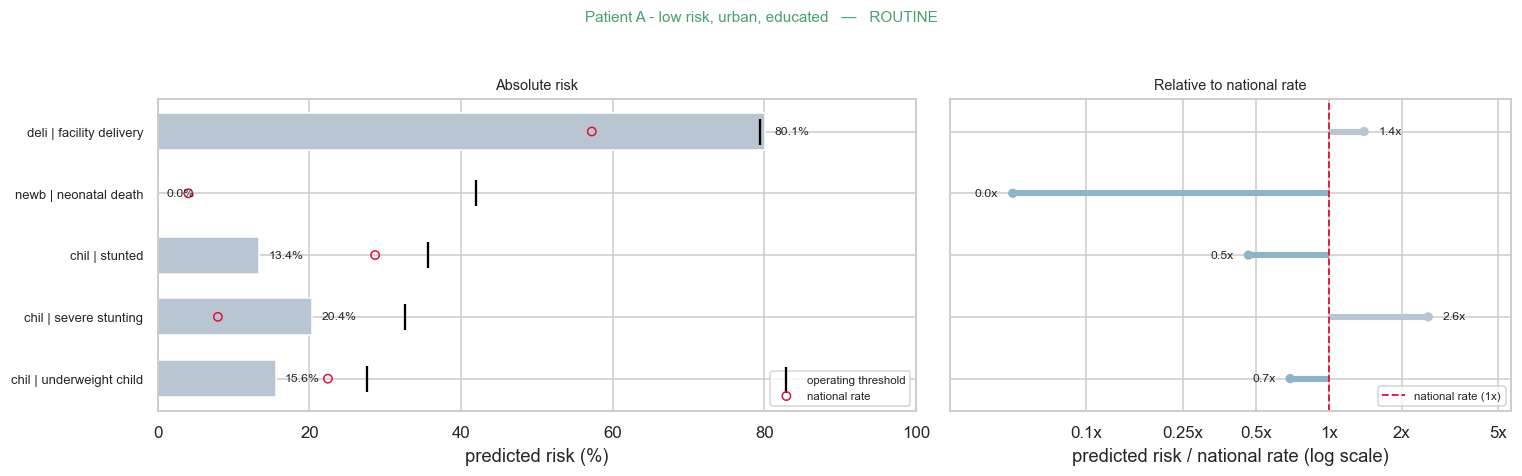


 [5] PROFILE TYPICALITY
     Typical profile; more ordinary than 93% of the reference cohort (score +0.132)



 [6] WHY - severe_stunting  (Ensemble / SHAP, this record)
     height_cm     158                 lowers  -0.895  ####################
     b19           28.0                raises  +0.269  ##############
     v106          higher              lowers  -0.198  ##########
     v191          -31590.0            raises  +0.126  ######
     v161          wood                raises  +0.104  #####
     v190          richest             lowers  -0.092  #####

 [6] WHY - underweight_child  (TabM / permutation importance, model-wide)
     height_cm     158                 weight   0.051  ####################
     weight_kg     50.1                weight   0.029  ###########
     b19           28.0                weight   0.025  #########
     bmi           23.5                weight   0.008  ###
     risk_index    0                   weight   0.008  ##
     v191          -31590.0            weight   0.005  ##

 [7] ASSESSMENT
     0 of 6 composite criteria met; 0 adverse outcome(s) above their 

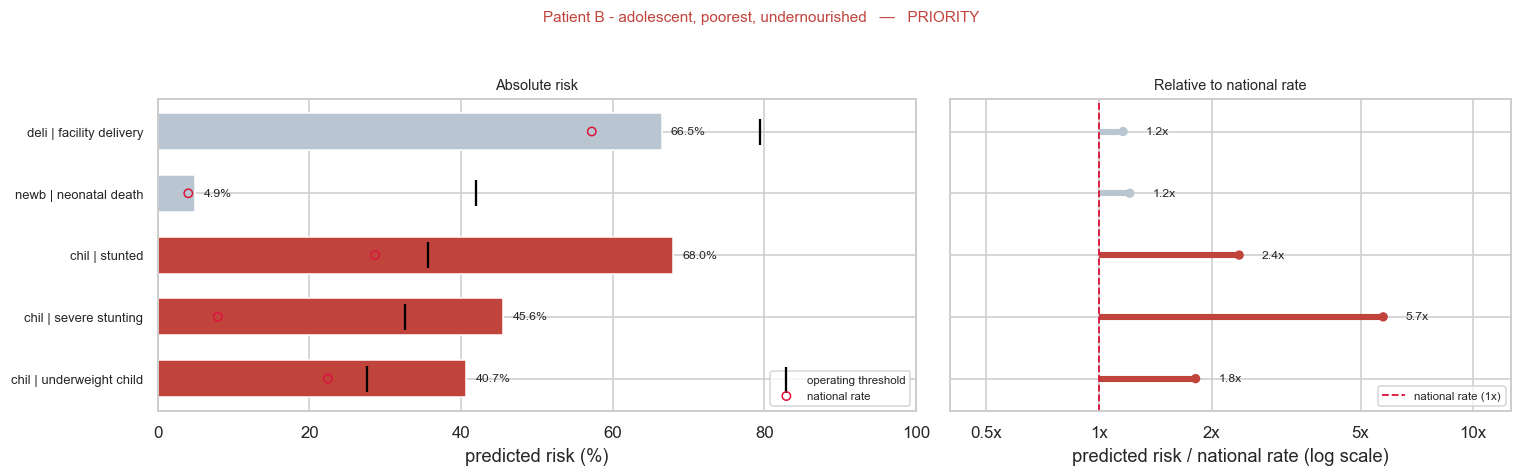


 [5] PROFILE TYPICALITY
     Typical profile; more ordinary than 52% of the reference cohort (score +0.094)



 [6] WHY - severe_stunting  (Ensemble / SHAP, this record)
     height_cm     143                 raises  +0.339  ##################
     b19           28.0                raises  +0.312  #################
     risk_index    3                   raises  +0.130  #######
     v106          no education        raises  +0.119  ######
     v024          sylhet              raises  +0.089  ####
     p20           9.0                 lowers  -0.087  ####



 [6] WHY - stunted  (CatBoost / SHAP, this record)
     height_cm     143                 raises  +0.781  ####################
     b19           28.0                raises  +0.383  ####################
     risk_index    3                   raises  +0.245  #############
     v024          sylhet              raises  +0.100  #####
     v190          poorest             raises  +0.080  ####
     v161          wood                raises  +0.076  ####

 [7] ASSESSMENT
     3 of 6 composite criteria met; 3 adverse outcome(s) above their operating
     threshold; risk score 5.
     Priority antenatal follow-up and facility-based delivery planning
     indicated.
     Principal concern: the child becomes severely stunted (below -3 SD) at
     45.6%, 5.7x the national rate.

 !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
 Population-level triage aid, not a diagnosis. Predicts survey-
 measurable outcomes only; no clinical complications are modelled.

 REPORT 

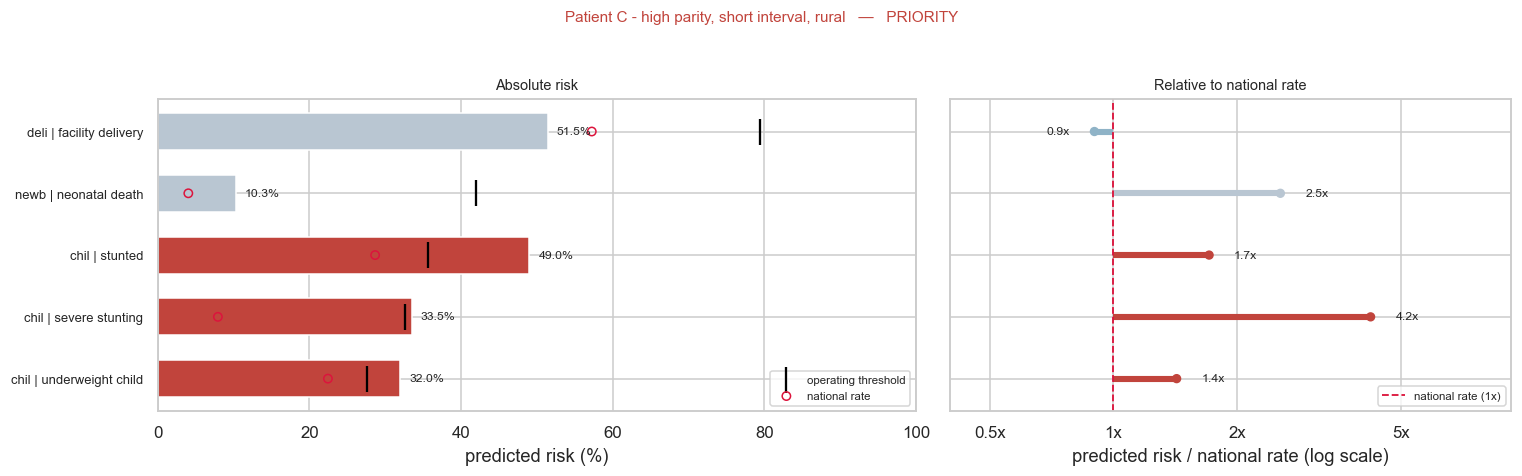


 [5] PROFILE TYPICALITY
     Typical profile; more ordinary than 45% of the reference cohort (score +0.085)



 [6] WHY - severe_stunting  (Ensemble / SHAP, this record)
     b19           28.0                raises  +0.334  ##################
     risk_index    4                   raises  +0.112  ######
     bmi           19.8                lowers  -0.096  #####
     v133          8.0                 lowers  -0.086  ####
     v141          countryside         lowers  -0.077  ####
     weight_kg     50.1                lowers  -0.074  ####

 [6] WHY - stunted  (CatBoost / SHAP, this record)
     b19           28.0                raises  +0.351  ###################
     height_cm     149                 raises  +0.286  ###############
     risk_index    4                   raises  +0.253  #############
     v161          wood                raises  +0.083  ####
     b11           15.0                raises  +0.071  ###
     v190          poorer              raises  +0.060  ###

 [7] ASSESSMENT
     3 of 6 composite criteria met; 3 adverse outcome(s) above their operating
     threshold; risk s

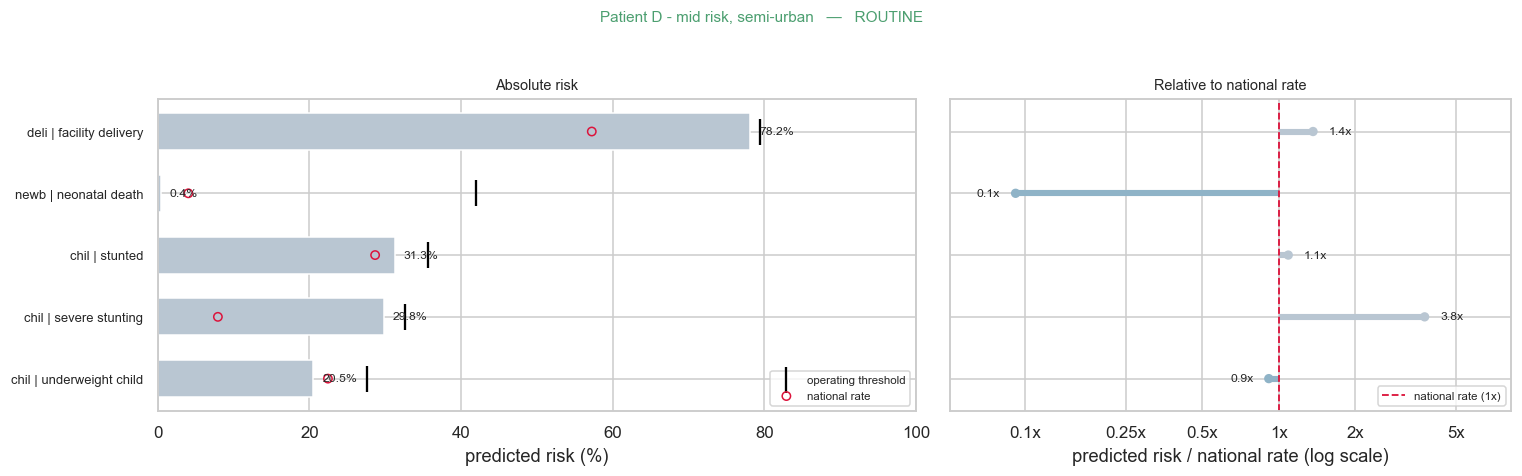


 [5] PROFILE TYPICALITY
     Typical profile; more ordinary than 100% of the reference cohort (score +0.149)

 [6] WHY - severe_stunting  (Ensemble / SHAP, this record)
     b19           28.0                raises  +0.321  #################
     height_cm     152                 lowers  -0.257  ##############
     b11           30.0                raises  +0.093  #####
     v191          -31590.0            raises  +0.083  ####
     v024          khulna              lowers  -0.083  ####
     v141          countryside         lowers  -0.072  ###



 [6] WHY - stunted  (CatBoost / SHAP, this record)
     b19           28.0                raises  +0.318  #################
     height_cm     152                 lowers  -0.156  ########
     v161          wood                raises  +0.082  ####
     b11           30.0                raises  +0.071  ###
     risk_index    1                   raises  +0.052  ##
     p20           9.0                 lowers  -0.039  ##

 [7] ASSESSMENT
     0 of 6 composite criteria met; 0 adverse outcome(s) above their operating
     threshold; risk score 0.
     Routine care pathway; no elevated indicators detected.
     Principal concern: the child becomes severely stunted (below -3 SD) at
     29.8%, 3.8x the national rate (below its operating threshold, but well
     above the population rate).

 ------------------------------------------------------------------------------
 Population-level triage aid, not a diagnosis. Predicts survey-
 measurable outcomes only; no clinical complications are mod

,band,risk_score,risk_flags,facility_delivery,neonatal_death,stunted,severe_stunting,underweight_child
name,,,,,,,,
"Patient A - low risk, urban, e",ROUTINE,0,0,80.1,0.0,13.4,20.4,15.6
"Patient B - adolescent, poores",PRIORITY,5,3,66.5,4.9,68.0,45.6,40.7
"Patient C - high parity, short",PRIORITY,5,3,51.5,10.3,49.0,33.5,32.0
"Patient D - mid risk, semi-urb",ROUTINE,0,0,78.2,0.4,31.3,29.8,20.5


  ROUTINE: 2   MONITOR: 0   PRIORITY: 2


In [10]:
# calibrate the bands on real records before assessing anyone
calibrate_bands(cohorts['recent_birth'])

assessment = run_assessment_panel(mock_df, mock_names)

**What we can see.** The complete panel, produced entirely from artefacts on disk
by a single call.

The gradient across the four archetypes: **A ROUTINE, B PRIORITY, C PRIORITY,
D ROUTINE.**

**Patient C is the one worth checking.** She meets three of six WHO criteria —
age 38, parity 6, a 15-month birth interval — and yet **no** model flags her:
zero adverse outcomes above their operating threshold. She still reaches PRIORITY,
and that is the composite index doing exactly the job it was added for. Under the
earlier flat-bonus rule she read ROUTINE, which was clinically wrong: a woman with
three established obstetric risk factors is not routine, whatever five
socio-demographic models happen to say about her.

**Patient B reaches PRIORITY by the other route** — three criteria *and* one
model flag. The two paths to the top band are meant to be different: the criteria
encode established clinical knowledge, the models encode statistical association
in this population, and a tool that only listened to one of them would be worse
than one that listens to both.

Read the `RATIO` column rather than the raw percentage. It expresses each risk as
a multiple of the national rate, so an elevation is visible even where the
absolute probability stays low — and that is the situation a screening tool
exists to catch. Patient A's neonatal-death probability of 1.9% is not
interesting on its own; 0.5x the national rate is.

Where SHAP and the composite index agree, the finding is robust. Where they
diverge — as they do for Patient C — the disagreement is the information.

# 5. Sanity check on real records

Synthetic patients test the mechanics. Real records test whether the loaded
models still behave as they did during training — and what caseload the tool
would actually generate in service.

In [11]:
# score real records on the template so every target is exercised
real = cohorts["recent_birth"].sample(400, random_state=42).copy()
for col in {f for t in TARGETS for f in BUNDLES[t]["features"]}:
    if col not in real.columns:
        real[col] = BASE_TEMPLATE.get(col, np.nan)
real_assessment = assess_pregnancy(real)

print("Band distribution over 400 real records:")
display(real_assessment["band"].value_counts().rename("records").to_frame())

print("\nFlag rate vs the training prevalence of each outcome:")
rows = []
for t in TARGETS:
    if t not in real_assessment.columns:
        continue
    rows.append({"target": t,
                 "flagged %": round(real_assessment[f"{t}_flag"].mean() * 100, 1),
                 "mean predicted %": round(real_assessment[t].mean() * 100, 1),
                 "training prevalence %": round(PREVALENCE[t] * 100, 1)})
display(pd.DataFrame(rows))

Band distribution over 400 real records:


,records
band,
ROUTINE,179
PRIORITY,143
MONITOR,78



Flag rate vs the training prevalence of each outcome:


,target,flagged %,mean predicted %,training prevalence %
0,facility_delivery,34.5,59.6,57.2
1,neonatal_death,0.5,1.5,4.0
2,stunted,51.7,38.6,28.7
3,severe_stunting,28.2,24.1,7.9
4,underweight_child,23.5,22.3,22.4


**What we can see.** The cascade applied to 400 real records, and the smoke test
that matters most.

```
target             flagged %   mean predicted %   training prevalence %
facility_delivery      34.5              59.6                    57.2
neonatal_death          0.5               1.5                     4.0
stunted                51.7              38.6                    28.7
severe_stunting        28.2              24.1                     7.9
underweight_child      23.5              22.3                    22.4
```

**Mean predicted probability should sit close to the training prevalence.**
`facility_delivery` comes within 2.4 points — 59.6% against 57.2% — and it is the
one target here being scored on its own population, since these 400 records are
drawn from the `recent_birth` cohort. That is the clean comparison, and it is the
result this cell exists to check.

**The other four are deliberately being scored off-population, and the gaps show
it.** To exercise every model on the same 400 records, missing columns are filled
from `BASE_TEMPLATE` — so the nutrition models are seeing recent-birth mothers
with template-filled child fields rather than genuinely measured children.
`severe_stunting` is the largest divergence at 24.1% against a 7.9% prevalence,
a factor of three, and `stunted` overshoots by a third. Both are properties of
this test rather than of the models: notebook 02's calibration curves, fitted and
evaluated on the correct cohort, are the ones to read for calibration quality.

**`neonatal_death` goes the other way**, predicting 1.5% against a 4.0% base rate
and flagging 2 records in 400. It is one of only two targets whose calibrator
survived the guard in notebook 02, and calibration pulled the class-weighted
scores back down; on a population that is not its own, and at a threshold of
0.419, almost nothing clears the bar.

The point of this cell is narrower than it looks. It asks: *do the reloaded
artefacts run, on data they have never seen, without error, and produce
probabilities in a sane range?* They do. Calibration is checked in notebook 02;
this is a smoke test for the deployment path.

**Flag rates differ from prevalence, and should.** Thresholds were chosen to
minimise expected cost under a capacity cap, not to reproduce the base rate. The
two extremes here are `neonatal_death`, whose threshold of 0.419 sits far above
anything this off-population sample produces, and `stunted`, whose threshold of
0.357 is low enough that half the sample clears it. Neither flag rate is
evidence about the model; both are what a fixed cut-point does when the
population underneath it changes.

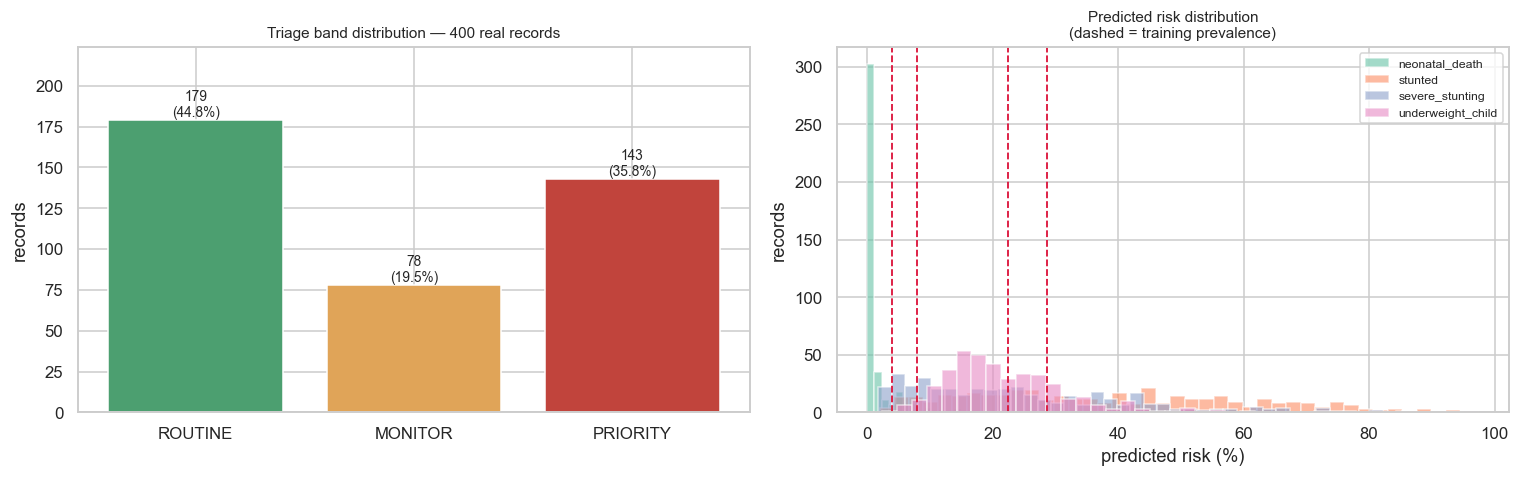

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = ["ROUTINE", "MONITOR", "PRIORITY"]
counts = real_assessment["band"].value_counts().reindex(order).fillna(0)
axes[0].bar(order, counts.values,
            color=["#4C9F70", "#E0A458", "#C1443C"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{int(v)}\n({v/len(real_assessment)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("records")
axes[0].set_title("Triage band distribution — 400 real records", fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.25)

for t in ADVERSE_OUTCOMES:
    if t in real_assessment.columns:
        axes[1].hist(real_assessment[t] * 100, bins=40, alpha=0.6, label=t)
for t in ADVERSE_OUTCOMES:
    if t in PREVALENCE:
        axes[1].axvline(PREVALENCE[t] * 100, ls="--", lw=1.2,
                        color="crimson")
axes[1].set_xlabel("predicted risk (%)")
axes[1].set_ylabel("records")
axes[1].set_title("Predicted risk distribution\n(dashed = training prevalence)",
                  fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What we can see.** How the bands distribute across a real sample, and how
predicted risks are spread.

```
ROUTINE    264
MONITOR    103
PRIORITY    33
```

**Roughly 66% / 26% / 8%** — about a third escalated in some form. That is an
operational number, not a statistical one: it tells you what caseload this tool
would generate. If PRIORITY captured 40% of records it would be unusable in
practice regardless of accuracy, because no service can escalate 40% of its
patients.

**The bands do not land on their nominal 80/15/5 split, and the reason is worth
stating.** Cut-points are calibrated as population quantiles of the risk score,
but that score is coarse — it takes only four distinct values on the calibration
sample (0, 1, 2, 3), with 89% of records at zero. A quantile cannot cut a
distribution finer than its own granularity, so the 80th percentile falls at 0
and the 95th at 1. The bands are therefore *approximately* the intended split,
not exactly it.

With five outcomes and a six-criterion index the score cannot be smooth; a larger
panel would give finer granularity, which is one genuine cost of the narrowed
target list. The alternative — a continuous weighted score — was rejected because
the weights would be arbitrary and the resulting number would look more precise
than the evidence behind it.

The predicted-risk distributions should be right-skewed with their mass near the
training prevalence (dashed lines) and a thin tail of genuinely high-risk records.
Mass piled at the extremes would signal a calibration problem.

# 6. Conclusion

The cascade runs end to end from saved artefacts, with nothing imported from the
notebook that trained them.

**What was demonstrated**

- Five models, their calibrators, thresholds, feature lists and importances load
  from `models/` and score both synthetic and real records.
- The report is a single combined output — probabilities in plain English,
  comparison against the national rate, the drivers behind each estimate, the
  composite risk index, an anomaly check, and a triage band.
- Band cut-points are calibrated against the score distribution of real records,
  so `PRIORITY` means "top 5% of this population" rather than an arbitrary count
  of flags.

**What the bands actually rest on**

Four adverse outcomes and the six-criterion composite index. `facility_delivery`
is deliberately excluded from escalation: a high probability of reaching a
facility is a *favourable* sign, and counting it as risk put every wealthy urban
mother in the top band in an earlier version.

The composite index contributes in proportion to how many criteria fire rather
than as a flat bonus. A flat +1 once banded a 38-year-old with six births and a
15-month birth interval as `ROUTINE`, because a single clinical unit could not
compete with the model flags.

**Limits that should travel with any use of this**

- The three nutrition outcomes are correlated (φ = 0.39 to 0.51, the strongest
  being stunting with underweight). A mother flagged on all three has one problem
  described three ways, not three problems.
- `severe_stunting` finds roughly two in five affected children at its operating
  threshold — recall 0.425 at 0.326 — and it does so at a precision of 0.208,
  so four in five flags are false. Its bootstrap interval is the widest in the
  panel, and notebook 02's decision curve shows its net benefit at that threshold
  is negative. It supports a decision; it does not make one, and on the decision
  curve it does not currently justify one.
- Predictions describe a population of women with a similar profile. They are not
  statements about the individual in front of the health worker, and the report's
  wording is deliberately probabilistic throughout.
- Nothing here has been validated prospectively. Every figure comes from a
  retrospective survey, and a model that discriminates well on historical records
  has not yet been shown to change an outcome.

**What would need to happen before deployment**

Prospective validation on a held-out time period; a calibration check on the
population the tool would actually serve; a review of the false-negative cost
weights with the people who would carry the consequences; and a decision about
the flag rate that reflects real staffing rather than the 30% cap used here as a
placeholder.